<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travel Time Inversion — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 11 — Travel Time Inversion: the Herglotz-Wiechert Method**

This notebook implements both inversion techniques from lecture:

1. **The Herglotz-Wiechert formula** — recovering a continuous v(z) profile directly from a synthetic X(p) curve.
2. **The \u03c4(p) = Gh linear system** — solving the straight-line-fitting / layer-cake inversion as a matrix problem, and verifying it against the lecture's worked example by hand.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (7, 8)

## Part 1 — The Herglotz-Wiechert Inversion

We'll test the formula the honest way: start from a **known** velocity model, forward-compute its X(p) curve exactly as in Lecture 9's ray tracing, then see whether the Herglotz-Wiechert integral can recover the original model from that curve alone.

$$z(u) = \frac{1}{\pi}\int_u^{u_e} \frac{X(p)}{\sqrt{p^2-u^2}}\,dp$$

(This is the pre-integration-by-parts form from lecture — integrating directly over $p$ avoids needing to numerically invert $X(p)$ to find $X(u)$ first.)

In [2]:
# A simple linear velocity gradient: v(z) = v0 + b*z
v0, b = 4.0, 0.5
zmax = 12.0

def velocity(z):
    return v0 + b * z

def trace_ray_xt(p, dz=0.005):
    """1-D ray tracer (from Lecture 9): returns one-way (x, z_turn, t)."""
    z, x, t = 0.0, 0.0, 0.0
    while z < zmax:
        u = 1.0 / velocity(z)
        arg = u**2 - p**2
        if arg <= 1e-9:
            break
        eta = np.sqrt(arg)
        x += (p / eta) * dz
        t += (u**2 / eta) * dz
        z += dz
    return x, z, t

In [3]:
# Forward-compute X(p). Only ray parameters that genuinely TURN within
# z < zmax are valid (p must exceed u(zmax)) -- smaller p would need a
# deeper model to turn properly and must be excluded.
u_surface = 1.0 / velocity(0)
u_at_zmax = 1.0 / velocity(zmax)
print(f"u_surface = {u_surface:.4f} s/km   u_at_zmax = {u_at_zmax:.4f} s/km")

p_values = np.linspace(u_at_zmax * 1.001, u_surface * 0.999, 400)
X_vals = []
for p in p_values:
    x, zt, t = trace_ray_xt(p)
    X_vals.append(2 * x)   # two-way distance, the standard X(p) convention
X_vals = np.array(X_vals)

u_surface = 0.2500 s/km   u_at_zmax = 0.1000 s/km


In [4]:
def hw_invert(u_target, p_arr, X_arr):
    """Direct Herglotz-Wiechert integral (pre-by-parts form)."""
    mask = p_arr > u_target + 1e-6
    p_sub, X_sub = p_arr[mask], X_arr[mask]
    integrand = X_sub / np.sqrt(p_sub**2 - u_target**2)
    return (1.0 / np.pi) * np.trapezoid(integrand, p_sub)

u_targets = np.linspace(u_surface * 0.99, u_at_zmax * 1.01, 20)
z_recovered = np.array([hw_invert(u, p_values, X_vals) for u in u_targets])
v_recovered = 1.0 / u_targets

# Compare to the known analytic answer for a linear gradient: z = (v - v0) / b
z_true = (v_recovered - v0) / b
max_err = np.max(np.abs(z_recovered - z_true))
print(f"Max |z_recovered - z_true| = {max_err:.3f} km  (out of a {zmax:.0f} km deep model)")

Max |z_recovered - z_true| = 0.770 km  (out of a 12 km deep model)


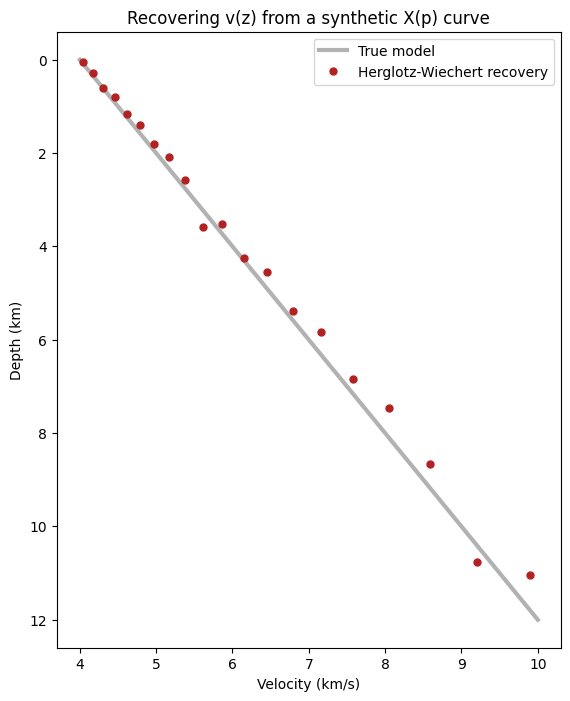

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 8))
z_line = np.linspace(0, zmax, 200)
ax.plot(velocity(z_line), z_line, color="gray", linewidth=3, alpha=0.6, label="True model")
ax.plot(v_recovered, z_recovered, "o", color="firebrick", markersize=5, label="Herglotz-Wiechert recovery")
ax.invert_yaxis()
ax.set_xlabel("Velocity (km/s)"); ax.set_ylabel("Depth (km)")
ax.set_title("Recovering v(z) from a synthetic X(p) curve")
ax.legend()
plt.show()

The recovered points track the true model closely — confirming the Herglotz-Wiechert formula genuinely works when the input X(p) curve is clean, dense, and continuous. Try re-running this with a coarser `p_values` grid (fewer points) or adding random noise to `X_vals` to see exactly why the lecture calls this method fragile in practice.

## Part 2 — The \u03c4(p) = Gh Linear System

Now the practical, real-data-friendly method: build the lower-triangular G matrix directly from a set of layer slownesses and ray parameters, and solve for layer thicknesses. We'll verify this against the lecture's own worked example.

In [6]:
def build_G(u_layers, p_obs):
    """Lower-triangular G matrix: tau(p_j) = sum_i 2*sqrt(u_i^2 - p_j^2) * h_i  (i <= j).

    u_layers must include every layer down to and including the one each
    p_obs value critically refracts along the top of (see note below)."""
    n = len(p_obs)
    G = np.zeros((n, n))
    for j, p in enumerate(p_obs):
        for i in range(j + 1):
            G[j, i] = 2 * np.sqrt(u_layers[i]**2 - p**2)
    return G

**A subtlety worth flagging:** each head-wave ray parameter $p_j$ equals the slowness of the layer it critically refracts *along the top of* — which is the layer **below** the one whose thickness it's the first equation for, i.e. $p_j = u_{j+1}$, not $u_j$. (If $p_j$ equalled $u_j$ instead, that row's diagonal entry $\sqrt{u_j^2-p_j^2}$ would be exactly zero — a ray grazing critically within its own layer contributes nothing to that layer's vertical travel time.) The trivial direct-wave relation $\tau_1=0$ (from $p=u_1$) carries no information about layer thicknesses, so we only use the $n-1$ genuinely informative head-wave observations.

In [7]:
# The lecture's worked example: 3 layers, 2 informative head-wave observations
u_all = np.array([0.417, 0.267, 0.167])   # u1, u2, u3 (s/km) -- all three layer slownesses
p_obs = u_all[1:]                          # p1=u2, p2=u3 (the two head-wave ray parameters)
tau_obs = np.array([0.6, 1.6])             # tau(p1), tau(p2) intercepts read off the T-X curve

G = build_G(u_all, p_obs)
print("G matrix:\n", np.round(G, 3))

h = np.linalg.solve(G, tau_obs)
print(f"\nRecovered layer thicknesses: dz1={h[0]:.3f} km, dz2={h[1]:.3f} km")
print("Expected from lecture: dz1=0.937 km, dz2=2.12 km")
assert abs(h[0] - 0.937) < 0.01
assert abs(h[1] - 2.12) < 0.01
print("Matches the lecture's worked example.")

G matrix:
 [[0.641 0.   ]
 [0.764 0.417]]

Recovered layer thicknesses: dz1=0.937 km, dz2=2.122 km
Expected from lecture: dz1=0.937 km, dz2=2.12 km
Matches the lecture's worked example.


In [8]:
# Sanity check: use these thicknesses to forward-predict tau(p) and confirm we recover tau_obs
tau_predicted = G @ h
print("Predicted tau(p):", np.round(tau_predicted, 3))
print("Observed tau(p):  ", tau_obs)
assert np.allclose(tau_predicted, tau_obs)
print("\nForward and inverse calculations agree exactly.")

Predicted tau(p): [0.6 1.6]
Observed tau(p):   [0.6 1.6]

Forward and inverse calculations agree exactly.


### A larger synthetic test

Let's also confirm the method works for a deeper stack of layers where we know the true answer in advance — generate synthetic $\tau(p)$ data from a made-up layered model using the correct $p_j=u_{j+1}$ convention, then invert it and check we recover the same thicknesses. As above, this only recovers the top $n-1$ thicknesses from $n$ layers — the bottom layer's thickness isn't constrained by head-wave data alone.

In [9]:
# A synthetic 6-layer model -- we can recover the top 5 thicknesses
true_thicknesses = np.array([1.0, 1.5, 2.0, 1.0, 3.0])
true_velocities = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
true_u = 1.0 / true_velocities

p_synthetic = true_u[1:]                    # p_j = u_{j+1}, the head-wave convention
G_true = build_G(true_u, p_synthetic)
tau_synthetic = G_true @ true_thicknesses

# Now invert: pretend we only know the layer velocities (picked from T-X slopes) and tau_synthetic
h_recovered = np.linalg.solve(build_G(true_u, p_synthetic), tau_synthetic)

print("True thicknesses:     ", true_thicknesses)
print("Recovered thicknesses:", np.round(h_recovered, 6))
assert np.allclose(h_recovered, true_thicknesses)
print("\nExact recovery, as expected for noise-free synthetic data.")

True thicknesses:      [1.  1.5 2.  1.  3. ]
Recovered thicknesses: [1.  1.5 2.  1.  3. ]

Exact recovery, as expected for noise-free synthetic data.


### What happens with noisy data?

Real travel-time picks always have some timing error. Let's add a small amount of noise to `tau_synthetic` and see how the recovered thicknesses degrade — this is exactly the practical fragility the lecture warns about.

In [10]:
np.random.seed(0)
noise_level = 0.01  # seconds of picking error
tau_noisy = tau_synthetic + np.random.normal(0, noise_level, size=tau_synthetic.shape)

h_noisy = np.linalg.solve(build_G(true_u, p_synthetic), tau_noisy)
print("True thicknesses:      ", true_thicknesses)
print("Recovered (noisy data):", np.round(h_noisy, 3))
print("Relative errors (%):   ", np.round(100 * np.abs(h_noisy - true_thicknesses) / true_thicknesses, 1))

True thicknesses:       [1.  1.5 2.  1.  3. ]
Recovered (noisy data): [1.04  1.442 2.037 1.068 2.945]
Relative errors (%):    [4.  3.9 1.9 6.8 1.8]


Notice the deepest layers are the most sensitive to noise — small timing errors in the observed $\tau(p)$ propagate and can even flip the sign of a thickness estimate for a thin, deep layer. This is exactly why later lectures move toward more robust techniques (the slant-stack method, bounding curves, and regularized tomography).

## Summary & Further Resources

- **Herglotz-Wiechert** — an exact analytic inversion, `z(u) = (1/pi) * integral of X(p)/sqrt(p^2-u^2) dp`, that works beautifully on clean, dense, continuous data but is fragile with real, noisy, sparsely-sampled picks.
- **The \u03c4(p) = Gh system** — the practical, still-used-today alternative: a simple triangular linear system, solvable layer-by-layer, that degrades gracefully (if unevenly) with noise.
- **A key lesson** — the *same* underlying physics (the layered \u03c4(p) formula from Lecture 9) can be turned into either a fragile continuous-integral method or a robust discrete linear-algebra method, depending on how the problem is set up.

**For further reading:**
- Stein, S., and M. Wysession, *An Introduction to Seismology, Earthquakes, and Earth Structure*, Chapter 4 (Herglotz-Wiechert method) and Chapter 5 (seismic refraction / layer-cake inversion).
- Aki, K., and P. G. Richards, *Quantitative Seismology* — the classical reference for the Herglotz-Wiechert formula's original derivation.